# Event Profile Analysis

This notebook is Phase 4 of the Delhi AQI / GRAP project: **Event Profile
Analysis**.

**Scope of this notebook.** For every verified GRAP event, this notebook builds
one self-contained profile: the event's own details, five line charts showing
how PM2.5, PM10, temperature, humidity, and wind speed moved across its +/-7 day
window, and a missing-data summary for that window. Each chart is built by
averaging across the eight stations *for that one event only* -- there is no
averaging or comparison between events anywhere in this notebook.

**Deliberately out of scope here.** This notebook does not compare one event to
another, does not average or pool data across events, does not run any
statistical or hypothesis test, does not discuss whether GRAP was effective, and
draws no conclusions. Each event's section stands entirely on its own. Comparing
across events is left for the next notebook, previewed briefly at the very end
of this one.

> The notebook assumes it is run from the `notebooks/` folder, so the data paths
> below start with `../`. This notebook does not modify any earlier notebook.

# Setup

We load the event-window table built in the previous notebook, plus the raw
GRAP event calendar -- used here only for descriptive fields (action type, stage
transition, order title) that are not measurements and so were not carried into
the event-window table.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# The event-window table built in 06_event_window_construction.ipynb --
# one row per event x station x relative day, +/-7 days around each event.
event_windows = pd.read_csv('../data/processed/event_windows_master.csv')
event_windows['calendar_date'] = pd.to_datetime(event_windows['calendar_date'])

# The raw GRAP event calendar, filtered to verified events only. This supplies
# the descriptive fields (action type, stage transition, order title) that are
# not part of the event-window table because they are not per-station
# measurements.
grap_events = pd.read_csv('../data/raw/grap/grap_events_manual.csv')
grap_events = grap_events[grap_events['verified'] == 'Yes'].copy()
grap_events['effective_date'] = pd.to_datetime(grap_events['effective_date'])

print('event_windows rows:', len(event_windows))
print('verified events:', len(grap_events))
event_windows.head()

event_windows rows: 1080
verified events: 9


,event_id,event_date,relative_day,calendar_date,station_name,pm25_ugm3,pm10_ugm3,air_temp_c,rh_pct,wind_speed_ms,wind_dir_deg,grap_stage,is_before_event,is_event_day,is_after_event
0,E001,2022-10-05,-7,2022-09-28,Anand Vihar,90.35,559.60,28.50,70.08,0.42,254.59,0,True,False,False
1,E001,2022-10-05,-6,2022-09-29,Anand Vihar,97.47,574.12,28.51,67.69,0.46,246.48,0,True,False,False
2,E001,2022-10-05,-5,2022-09-30,Anand Vihar,107.01,554.88,28.62,68.46,0.45,240.65,0,True,False,False
3,E001,2022-10-05,-4,2022-10-01,Anand Vihar,108.54,567.01,28.94,66.04,0.52,210.88,0,True,False,False
4,E001,2022-10-05,-3,2022-10-02,Anand Vihar,94.53,543.08,29.11,62.74,0.69,230.77,0,True,False,False


**What this does.** Loads the event-window table produced by the previous
notebook, and separately loads the verified rows of the raw GRAP event
calendar. The event-window table supplies every measurement used in this
notebook; the event calendar supplies only the descriptive, non-numeric fields
shown in each event's profile.

**Why this matters.** Keeping the two files separate keeps the distinction
explicit: one file holds what was *measured*, the other holds what was
*officially declared*. Neither is derived from the other.

**How to read this.** Confirm the row counts look right -- `event_windows`
should have 15 rows per station per event, and `grap_events` should list one row
per verified event -- before building anything on top of them.

In [2]:
# One small, reusable helper: build the mean-across-stations series for a
# single event and a single measured variable, then plot it against relative
# day with a marker at the event day itself.
def plot_event_variable(event_id, event_date, column, y_label, color):
    event_rows = event_windows[event_windows['event_id'] == event_id]

    # Average across the 8 stations for this event only, one value per
    # relative day. Missing station-days are skipped automatically by mean().
    series_by_day = event_rows.groupby('relative_day')[column].mean()

    plt.figure(figsize=(8, 5))
    plt.plot(series_by_day.index, series_by_day.values, marker='o', color=color)
    plt.axvline(x=0, color='red', linestyle='--', label='GRAP Intervention')
    plt.title(f'{y_label} vs Relative Day -- {event_id} ({event_date})')
    plt.xlabel('Relative Day')
    plt.ylabel(y_label)
    plt.legend()
    plt.tight_layout()
    plt.show()

**What this does.** Defines one small function that, given an event id and a
measured column, filters the event-window table down to that single event,
averages the column across the eight stations for each relative day, and draws
one line chart with a dashed red vertical line at relative day 0 labelled "GRAP
Intervention".

**Why this matters.** Every event in this notebook needs the same five charts
built the same way. Defining the construction once, here, means every event's
charts are built identically -- the only thing that changes per event is which
event id and column are passed in.

**How to read this.** This cell produces no output by itself; it is used
repeatedly in every event section below.

# Event E001 -- 2022-10-05

In [3]:
# This event's id, used to select its rows out of the shared event-window table.
event_id = 'E001'

event_metadata = grap_events[grap_events['event_id'] == event_id].iloc[0]

event_profile = pd.DataFrame({
    'Field': ['Event ID', 'Event Date', 'Action Type', 'Stage Transition', 'Official Order Title'],
    'Value': [
        event_metadata['event_id'],
        event_metadata['effective_date'].date(),
        event_metadata['action_type'],
        f"Stage {event_metadata['stage_from']} -> Stage {event_metadata['stage_to']}",
        event_metadata['official_order_title'],
    ],
})
event_profile

,Field,Value
0,Event ID,E001
1,Event Date,2022-10-05
2,Action Type,invoke
3,Stage Transition,Stage 0 -> Stage 1
4,Official Order Title,Order dated 05.10.2022 for Implementation acti...


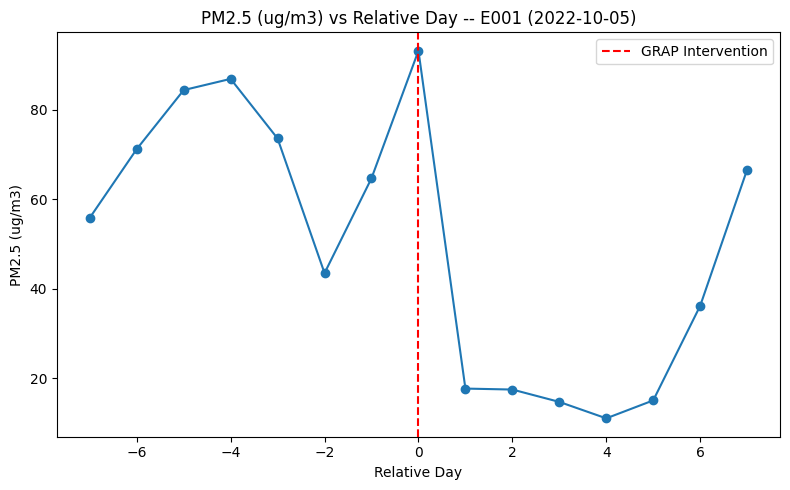

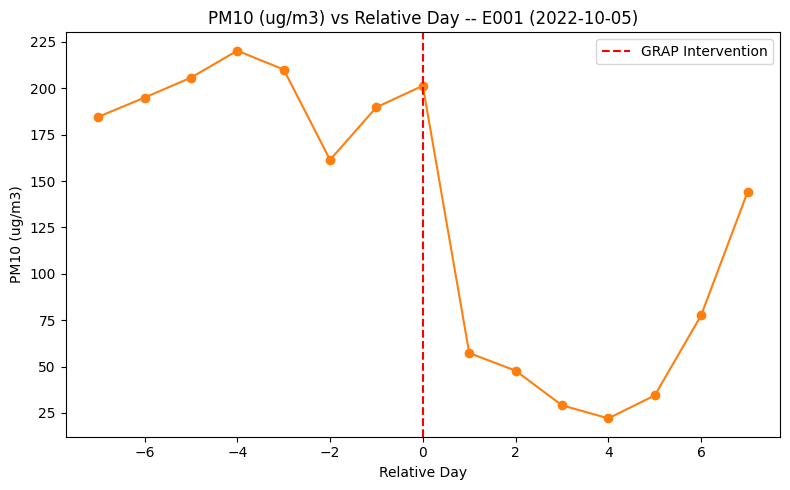

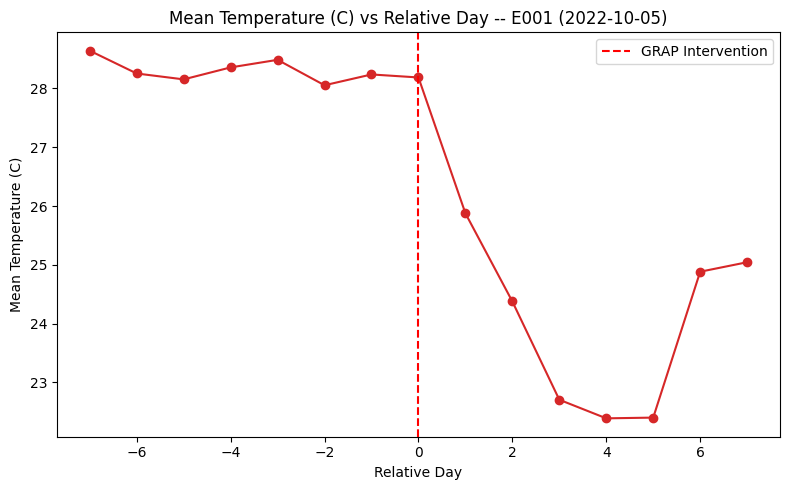

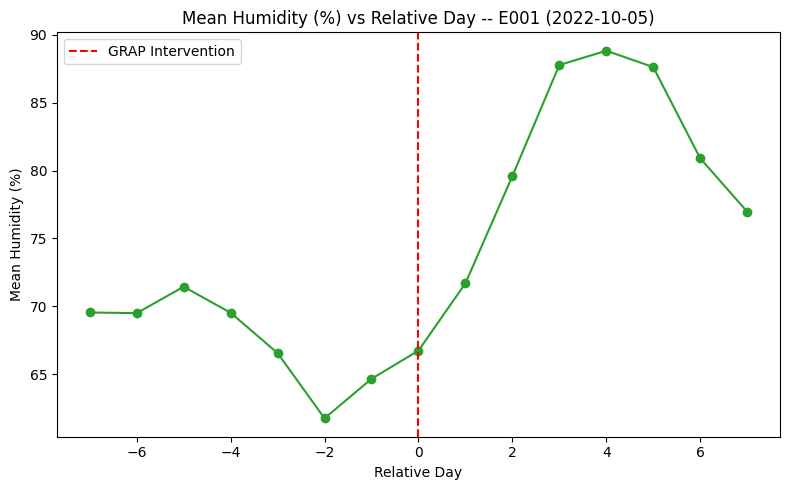

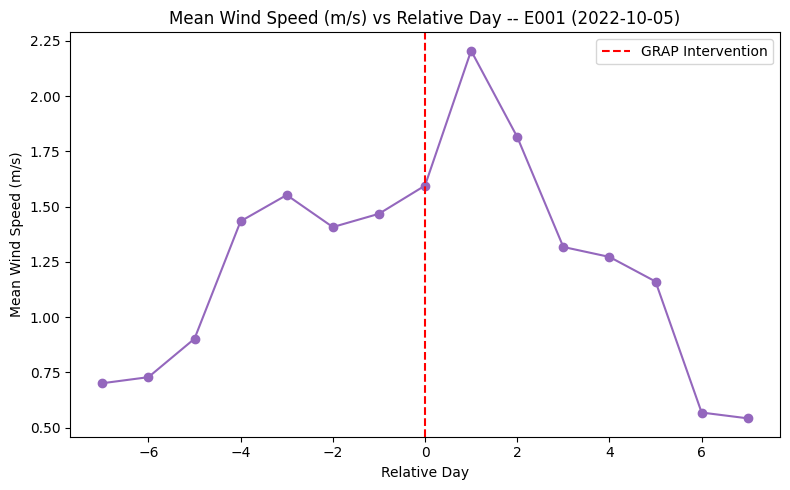

In [4]:
# The five line charts for this event, each averaged across the 8 stations.
plot_event_variable(event_id, '2022-10-05', 'pm25_ugm3', 'PM2.5 (ug/m3)', 'tab:blue')
plot_event_variable(event_id, '2022-10-05', 'pm10_ugm3', 'PM10 (ug/m3)', 'tab:orange')
plot_event_variable(event_id, '2022-10-05', 'air_temp_c', 'Mean Temperature (C)', 'tab:red')
plot_event_variable(event_id, '2022-10-05', 'rh_pct', 'Mean Humidity (%)', 'tab:green')
plot_event_variable(event_id, '2022-10-05', 'wind_speed_ms', 'Mean Wind Speed (m/s)', 'tab:purple')

In [5]:
# Missing-data summary for this event's window: how many of the 8 x 15 = 120
# rows are missing each measured variable.
event_rows = event_windows[event_windows['event_id'] == event_id]
measured_columns = ['pm25_ugm3', 'pm10_ugm3', 'air_temp_c', 'rh_pct', 'wind_speed_ms', 'wind_dir_deg']

missing_summary = event_rows[measured_columns].isnull().sum()
missing_summary = missing_summary.reset_index()
missing_summary.columns = ['Variable', 'Missing Count']
missing_summary['Missing % of Window'] = (missing_summary['Missing Count'] / len(event_rows) * 100).round(1)

missing_summary

,Variable,Missing Count,Missing % of Window
0,pm25_ugm3,0,0.0
1,pm10_ugm3,0,0.0
2,air_temp_c,0,0.0
3,rh_pct,0,0.0
4,wind_speed_ms,0,0.0
5,wind_dir_deg,0,0.0


**How to read these plots.** Each line is the average across the eight
stations for this event only, plotted day by day from 7 days before to 7 days
after the event. The dashed red "GRAP Intervention" line marks relative day 0,
the day the stage change took effect -- it is a time marker, not a claim about
what caused any change on either side of it.

**What analysts should observe.** Look at each line's shape on its own: whether
it is rising, falling, or flat in the days before the marker, and whether that
shape continues, reverses, or stays the same after it. Note how the pollutant
lines (PM2.5, PM10) sit alongside the weather lines (temperature, humidity, wind
speed) in the same window, and check the missing-data summary above before
reading too much into a day with few or no contributing stations.

**What NOT to conclude.** Do not read any change around the dashed line as
proof that the GRAP order caused it -- the same window also contains whatever
weather and seasonal movement was already underway, as documented in
`docs/analysis_plan.md`. Do not compare this event's chart to any other event's
chart -- that comparison is intentionally left for the next notebook. Do not
treat a single day's spike or dip as a stable pattern, and do not draw any
conclusion about whether GRAP is effective from this profile alone.

## Questions Raised

This event's profile raises the following questions, left unanswered here:

1. What happened in the days just before E001 that might be worth a closer look in a later notebook?
2. Does the 0 -> 1 transition on 2022-10-05 line up with a visible change in the PM2.5 line, or not?
3. Do PM2.5 and PM10 move together across this window, or does one lag the other?
4. How much of the shape seen in this window might be explained by the weather charts (temperature, humidity, wind speed) shown alongside it?
5. Would this event's profile look different with a narrower or wider relative-day window, per the sensitivity checks described in the analysis plan?

# Event E002 -- 2022-10-19

In [6]:
# This event's id, used to select its rows out of the shared event-window table.
event_id = 'E002'

event_metadata = grap_events[grap_events['event_id'] == event_id].iloc[0]

event_profile = pd.DataFrame({
    'Field': ['Event ID', 'Event Date', 'Action Type', 'Stage Transition', 'Official Order Title'],
    'Value': [
        event_metadata['event_id'],
        event_metadata['effective_date'].date(),
        event_metadata['action_type'],
        f"Stage {event_metadata['stage_from']} -> Stage {event_metadata['stage_to']}",
        event_metadata['official_order_title'],
    ],
})
event_profile

,Field,Value
0,Event ID,E002
1,Event Date,2022-10-19
2,Action Type,escalate
3,Stage Transition,Stage 1 -> Stage 2
4,Official Order Title,Order dated 19.10.2022 for Implementation of a...


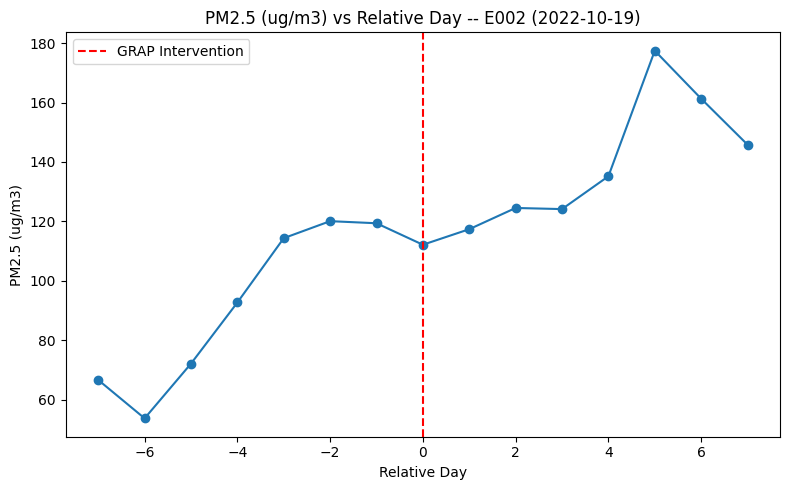

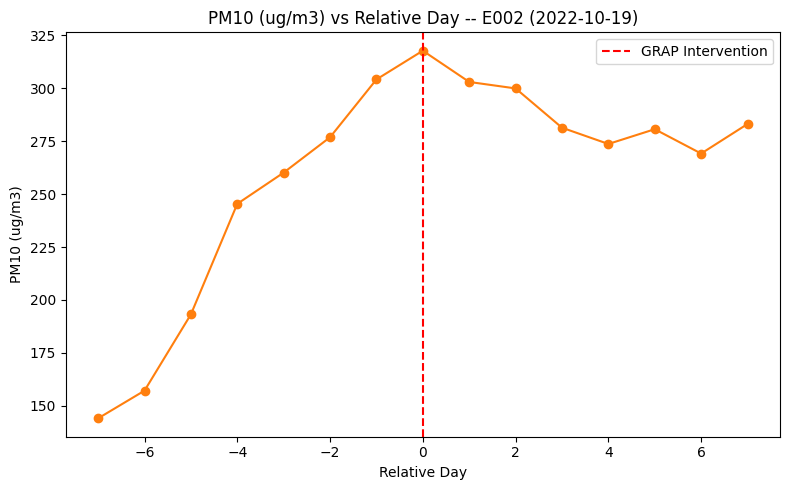

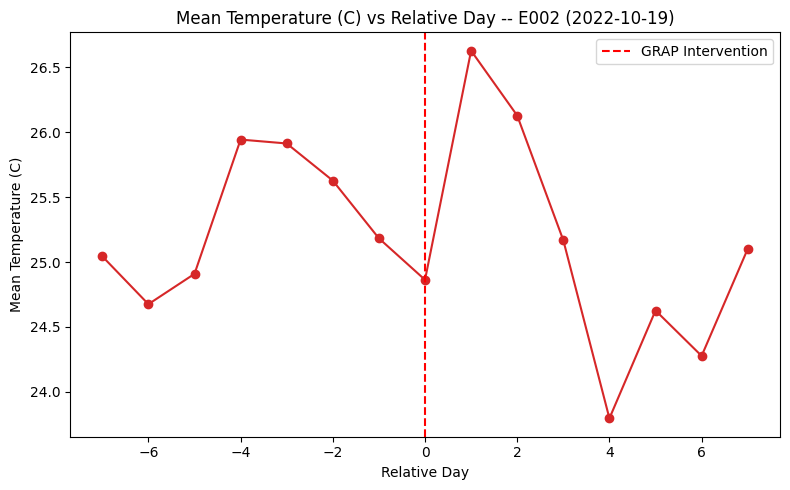

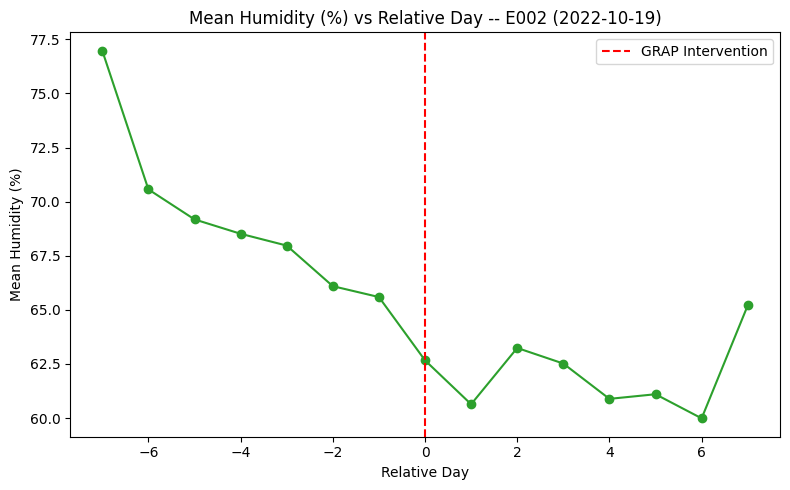

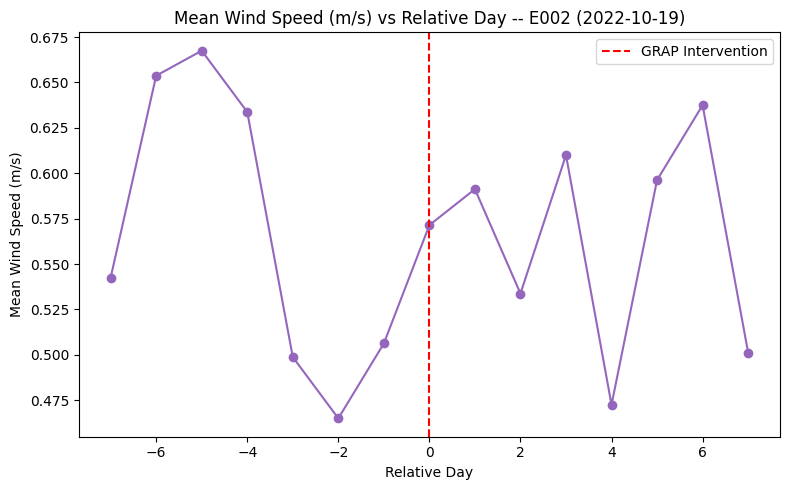

In [7]:
# The five line charts for this event, each averaged across the 8 stations.
plot_event_variable(event_id, '2022-10-19', 'pm25_ugm3', 'PM2.5 (ug/m3)', 'tab:blue')
plot_event_variable(event_id, '2022-10-19', 'pm10_ugm3', 'PM10 (ug/m3)', 'tab:orange')
plot_event_variable(event_id, '2022-10-19', 'air_temp_c', 'Mean Temperature (C)', 'tab:red')
plot_event_variable(event_id, '2022-10-19', 'rh_pct', 'Mean Humidity (%)', 'tab:green')
plot_event_variable(event_id, '2022-10-19', 'wind_speed_ms', 'Mean Wind Speed (m/s)', 'tab:purple')

In [8]:
# Missing-data summary for this event's window: how many of the 8 x 15 = 120
# rows are missing each measured variable.
event_rows = event_windows[event_windows['event_id'] == event_id]
measured_columns = ['pm25_ugm3', 'pm10_ugm3', 'air_temp_c', 'rh_pct', 'wind_speed_ms', 'wind_dir_deg']

missing_summary = event_rows[measured_columns].isnull().sum()
missing_summary = missing_summary.reset_index()
missing_summary.columns = ['Variable', 'Missing Count']
missing_summary['Missing % of Window'] = (missing_summary['Missing Count'] / len(event_rows) * 100).round(1)

missing_summary

,Variable,Missing Count,Missing % of Window
0,pm25_ugm3,0,0.0
1,pm10_ugm3,0,0.0
2,air_temp_c,1,0.8
3,rh_pct,1,0.8
4,wind_speed_ms,1,0.8
5,wind_dir_deg,1,0.8


**How to read these plots.** Each line is the average across the eight
stations for this event only, plotted day by day from 7 days before to 7 days
after the event. The dashed red "GRAP Intervention" line marks relative day 0,
the day the stage change took effect -- it is a time marker, not a claim about
what caused any change on either side of it.

**What analysts should observe.** Look at each line's shape on its own: whether
it is rising, falling, or flat in the days before the marker, and whether that
shape continues, reverses, or stays the same after it. Note how the pollutant
lines (PM2.5, PM10) sit alongside the weather lines (temperature, humidity, wind
speed) in the same window, and check the missing-data summary above before
reading too much into a day with few or no contributing stations.

**What NOT to conclude.** Do not read any change around the dashed line as
proof that the GRAP order caused it -- the same window also contains whatever
weather and seasonal movement was already underway, as documented in
`docs/analysis_plan.md`. Do not compare this event's chart to any other event's
chart -- that comparison is intentionally left for the next notebook. Do not
treat a single day's spike or dip as a stable pattern, and do not draw any
conclusion about whether GRAP is effective from this profile alone.

## Questions Raised

This event's profile raises the following questions, left unanswered here:

1. What happened in the days just before E002 that might be worth a closer look in a later notebook?
2. Does the 1 -> 2 transition on 2022-10-19 line up with a visible change in the PM2.5 line, or not?
3. Do PM2.5 and PM10 move together across this window, or does one lag the other?
4. How much of the shape seen in this window might be explained by the weather charts (temperature, humidity, wind speed) shown alongside it?
5. Would this event's profile look different with a narrower or wider relative-day window, per the sensitivity checks described in the analysis plan?

# Event E003 -- 2022-10-29

In [9]:
# This event's id, used to select its rows out of the shared event-window table.
event_id = 'E003'

event_metadata = grap_events[grap_events['event_id'] == event_id].iloc[0]

event_profile = pd.DataFrame({
    'Field': ['Event ID', 'Event Date', 'Action Type', 'Stage Transition', 'Official Order Title'],
    'Value': [
        event_metadata['event_id'],
        event_metadata['effective_date'].date(),
        event_metadata['action_type'],
        f"Stage {event_metadata['stage_from']} -> Stage {event_metadata['stage_to']}",
        event_metadata['official_order_title'],
    ],
})
event_profile

,Field,Value
0,Event ID,E003
1,Event Date,2022-10-29
2,Action Type,escalate
3,Stage Transition,Stage 2 -> Stage 3
4,Official Order Title,Order dated 29.10.2022 for implementation of a...


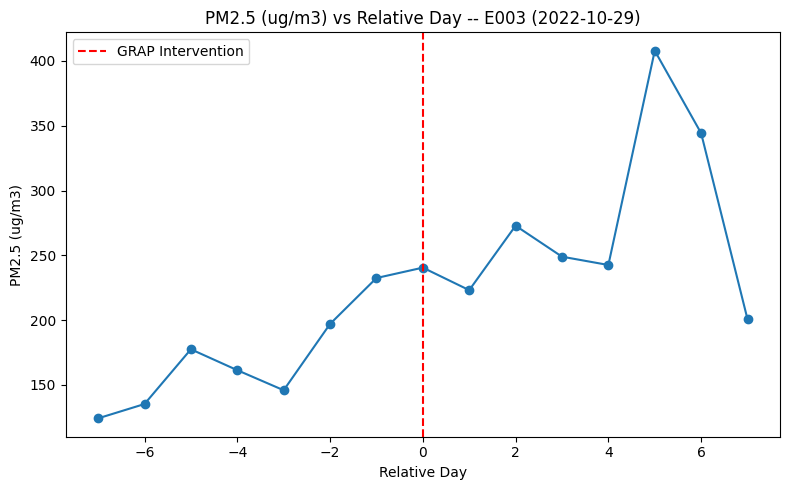

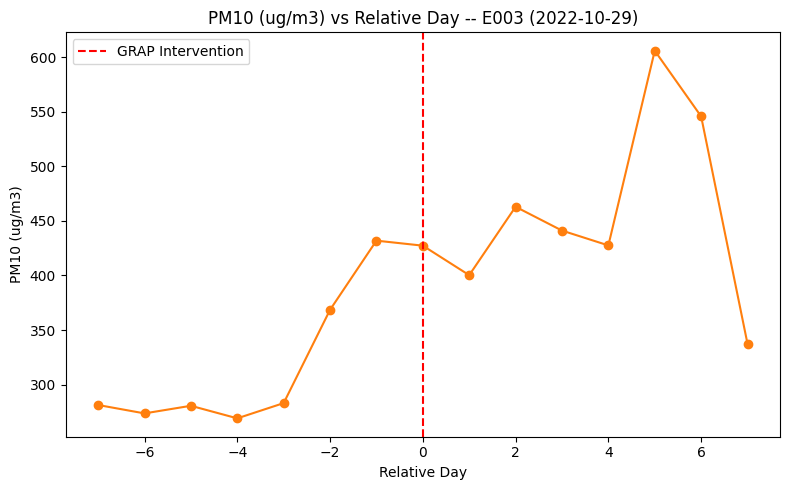

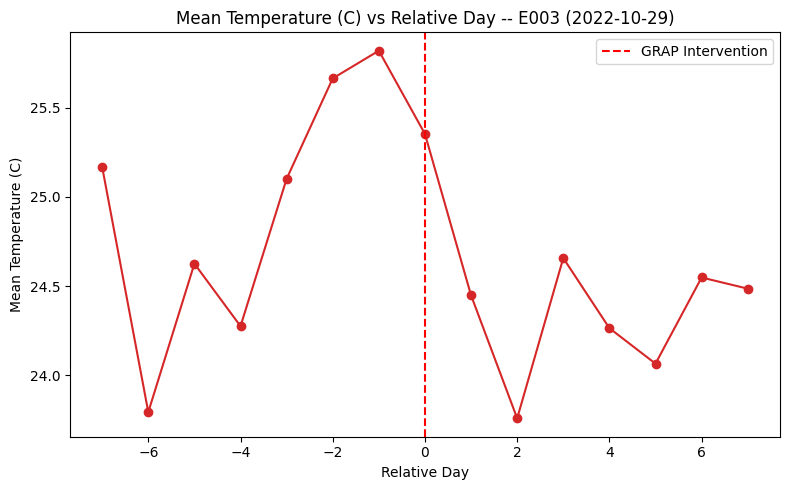

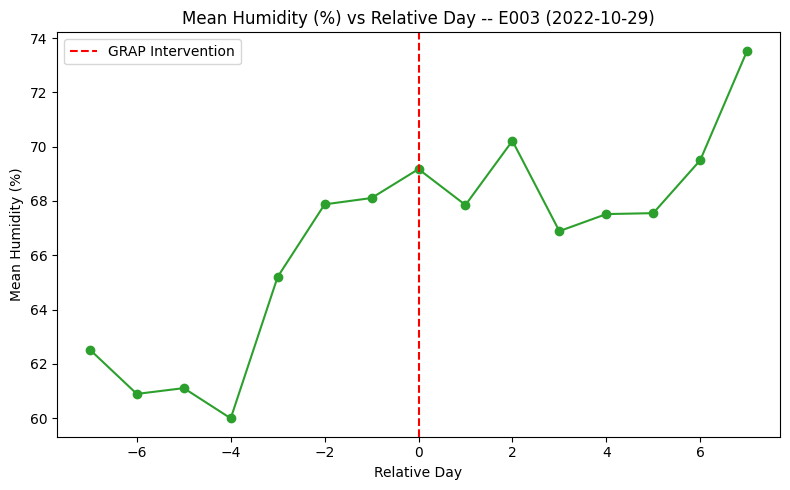

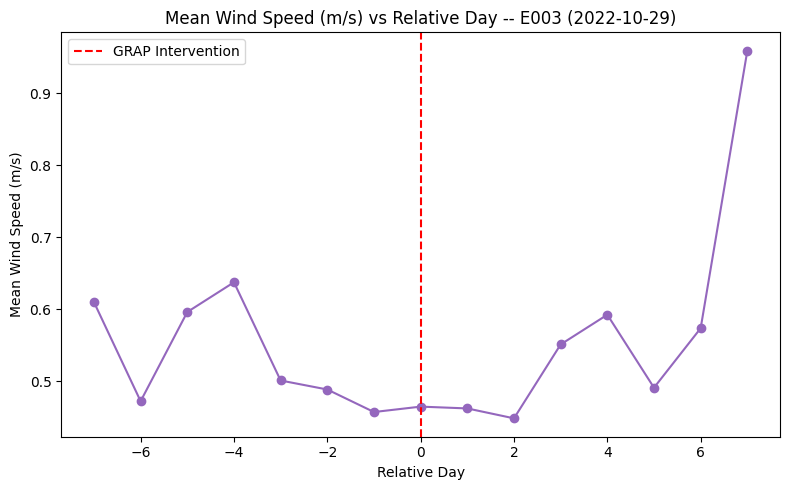

In [10]:
# The five line charts for this event, each averaged across the 8 stations.
plot_event_variable(event_id, '2022-10-29', 'pm25_ugm3', 'PM2.5 (ug/m3)', 'tab:blue')
plot_event_variable(event_id, '2022-10-29', 'pm10_ugm3', 'PM10 (ug/m3)', 'tab:orange')
plot_event_variable(event_id, '2022-10-29', 'air_temp_c', 'Mean Temperature (C)', 'tab:red')
plot_event_variable(event_id, '2022-10-29', 'rh_pct', 'Mean Humidity (%)', 'tab:green')
plot_event_variable(event_id, '2022-10-29', 'wind_speed_ms', 'Mean Wind Speed (m/s)', 'tab:purple')

In [11]:
# Missing-data summary for this event's window: how many of the 8 x 15 = 120
# rows are missing each measured variable.
event_rows = event_windows[event_windows['event_id'] == event_id]
measured_columns = ['pm25_ugm3', 'pm10_ugm3', 'air_temp_c', 'rh_pct', 'wind_speed_ms', 'wind_dir_deg']

missing_summary = event_rows[measured_columns].isnull().sum()
missing_summary = missing_summary.reset_index()
missing_summary.columns = ['Variable', 'Missing Count']
missing_summary['Missing % of Window'] = (missing_summary['Missing Count'] / len(event_rows) * 100).round(1)

missing_summary

,Variable,Missing Count,Missing % of Window
0,pm25_ugm3,0,0.0
1,pm10_ugm3,0,0.0
2,air_temp_c,0,0.0
3,rh_pct,0,0.0
4,wind_speed_ms,0,0.0
5,wind_dir_deg,0,0.0


**How to read these plots.** Each line is the average across the eight
stations for this event only, plotted day by day from 7 days before to 7 days
after the event. The dashed red "GRAP Intervention" line marks relative day 0,
the day the stage change took effect -- it is a time marker, not a claim about
what caused any change on either side of it.

**What analysts should observe.** Look at each line's shape on its own: whether
it is rising, falling, or flat in the days before the marker, and whether that
shape continues, reverses, or stays the same after it. Note how the pollutant
lines (PM2.5, PM10) sit alongside the weather lines (temperature, humidity, wind
speed) in the same window, and check the missing-data summary above before
reading too much into a day with few or no contributing stations.

**What NOT to conclude.** Do not read any change around the dashed line as
proof that the GRAP order caused it -- the same window also contains whatever
weather and seasonal movement was already underway, as documented in
`docs/analysis_plan.md`. Do not compare this event's chart to any other event's
chart -- that comparison is intentionally left for the next notebook. Do not
treat a single day's spike or dip as a stable pattern, and do not draw any
conclusion about whether GRAP is effective from this profile alone.

## Questions Raised

This event's profile raises the following questions, left unanswered here:

1. What happened in the days just before E003 that might be worth a closer look in a later notebook?
2. Does the 2 -> 3 transition on 2022-10-29 line up with a visible change in the PM2.5 line, or not?
3. Do PM2.5 and PM10 move together across this window, or does one lag the other?
4. How much of the shape seen in this window might be explained by the weather charts (temperature, humidity, wind speed) shown alongside it?
5. Would this event's profile look different with a narrower or wider relative-day window, per the sensitivity checks described in the analysis plan?

# Event E004 -- 2022-11-03

In [12]:
# This event's id, used to select its rows out of the shared event-window table.
event_id = 'E004'

event_metadata = grap_events[grap_events['event_id'] == event_id].iloc[0]

event_profile = pd.DataFrame({
    'Field': ['Event ID', 'Event Date', 'Action Type', 'Stage Transition', 'Official Order Title'],
    'Value': [
        event_metadata['event_id'],
        event_metadata['effective_date'].date(),
        event_metadata['action_type'],
        f"Stage {event_metadata['stage_from']} -> Stage {event_metadata['stage_to']}",
        event_metadata['official_order_title'],
    ],
})
event_profile

,Field,Value
0,Event ID,E004
1,Event Date,2022-11-03
2,Action Type,escalate
3,Stage Transition,Stage 3 -> Stage 4
4,Official Order Title,Order dated 03.11.2022 for Implementation of a...


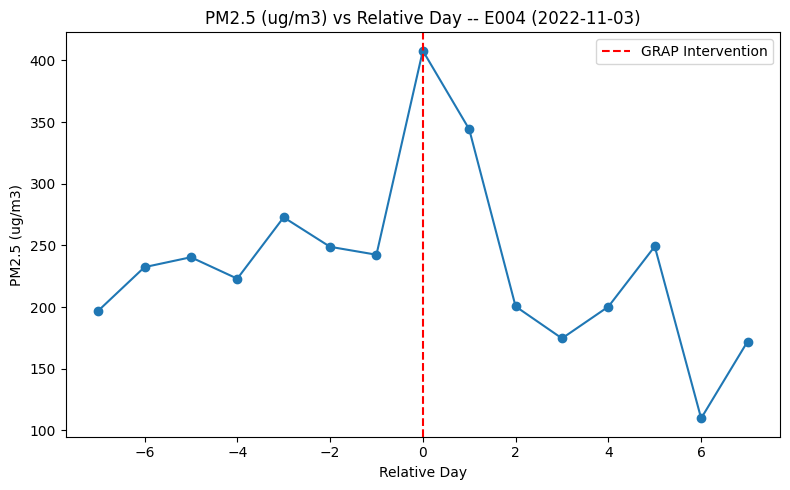

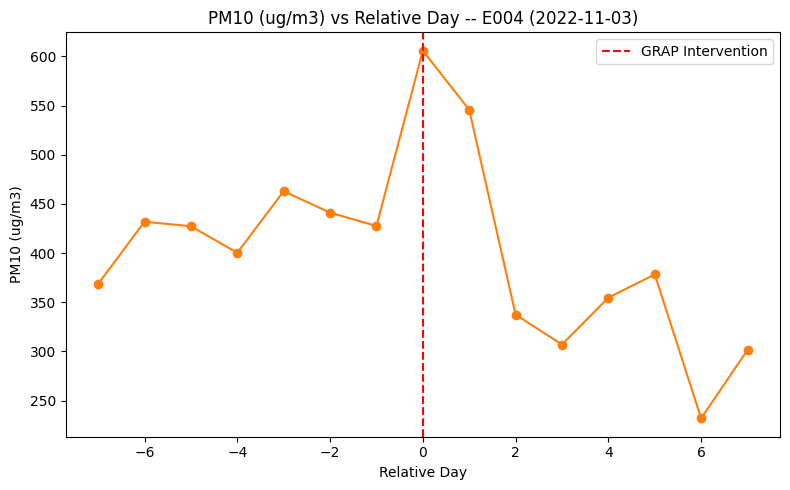

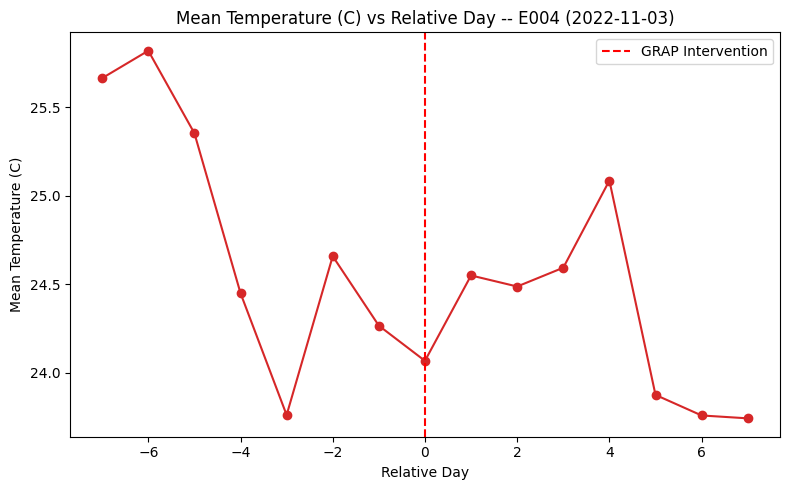

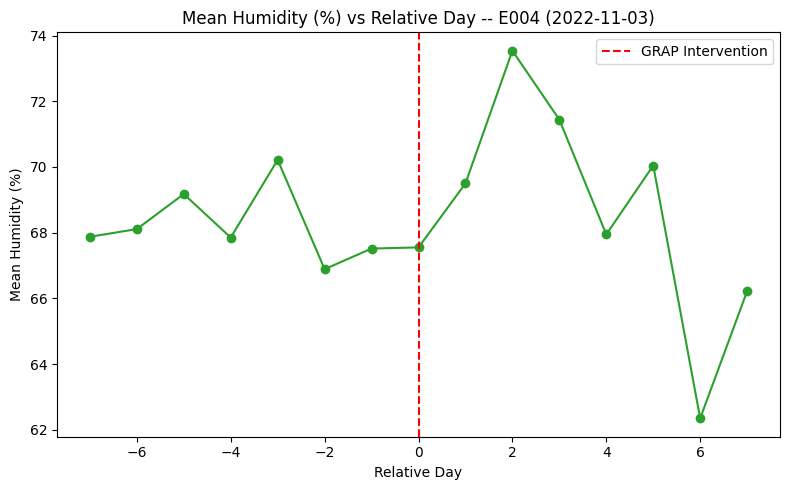

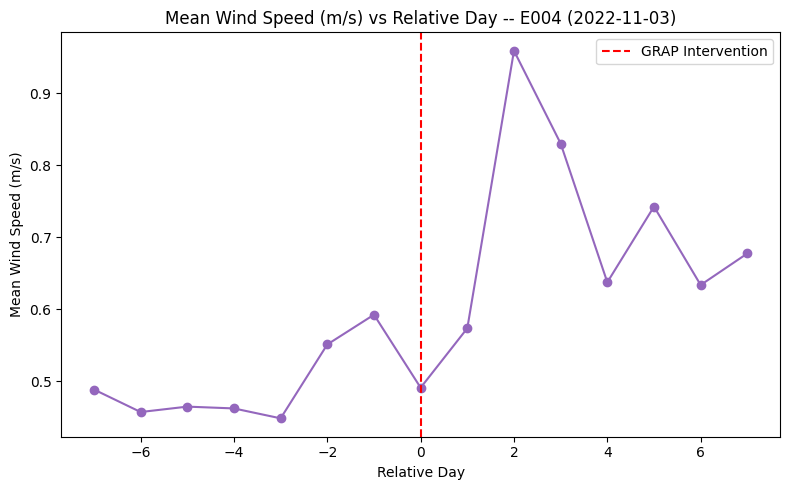

In [13]:
# The five line charts for this event, each averaged across the 8 stations.
plot_event_variable(event_id, '2022-11-03', 'pm25_ugm3', 'PM2.5 (ug/m3)', 'tab:blue')
plot_event_variable(event_id, '2022-11-03', 'pm10_ugm3', 'PM10 (ug/m3)', 'tab:orange')
plot_event_variable(event_id, '2022-11-03', 'air_temp_c', 'Mean Temperature (C)', 'tab:red')
plot_event_variable(event_id, '2022-11-03', 'rh_pct', 'Mean Humidity (%)', 'tab:green')
plot_event_variable(event_id, '2022-11-03', 'wind_speed_ms', 'Mean Wind Speed (m/s)', 'tab:purple')

In [14]:
# Missing-data summary for this event's window: how many of the 8 x 15 = 120
# rows are missing each measured variable.
event_rows = event_windows[event_windows['event_id'] == event_id]
measured_columns = ['pm25_ugm3', 'pm10_ugm3', 'air_temp_c', 'rh_pct', 'wind_speed_ms', 'wind_dir_deg']

missing_summary = event_rows[measured_columns].isnull().sum()
missing_summary = missing_summary.reset_index()
missing_summary.columns = ['Variable', 'Missing Count']
missing_summary['Missing % of Window'] = (missing_summary['Missing Count'] / len(event_rows) * 100).round(1)

missing_summary

,Variable,Missing Count,Missing % of Window
0,pm25_ugm3,0,0.0
1,pm10_ugm3,0,0.0
2,air_temp_c,0,0.0
3,rh_pct,0,0.0
4,wind_speed_ms,0,0.0
5,wind_dir_deg,0,0.0


**How to read these plots.** Each line is the average across the eight
stations for this event only, plotted day by day from 7 days before to 7 days
after the event. The dashed red "GRAP Intervention" line marks relative day 0,
the day the stage change took effect -- it is a time marker, not a claim about
what caused any change on either side of it.

**What analysts should observe.** Look at each line's shape on its own: whether
it is rising, falling, or flat in the days before the marker, and whether that
shape continues, reverses, or stays the same after it. Note how the pollutant
lines (PM2.5, PM10) sit alongside the weather lines (temperature, humidity, wind
speed) in the same window, and check the missing-data summary above before
reading too much into a day with few or no contributing stations.

**What NOT to conclude.** Do not read any change around the dashed line as
proof that the GRAP order caused it -- the same window also contains whatever
weather and seasonal movement was already underway, as documented in
`docs/analysis_plan.md`. Do not compare this event's chart to any other event's
chart -- that comparison is intentionally left for the next notebook. Do not
treat a single day's spike or dip as a stable pattern, and do not draw any
conclusion about whether GRAP is effective from this profile alone.

## Questions Raised

This event's profile raises the following questions, left unanswered here:

1. What happened in the days just before E004 that might be worth a closer look in a later notebook?
2. Does the 3 -> 4 transition on 2022-11-03 line up with a visible change in the PM2.5 line, or not?
3. Do PM2.5 and PM10 move together across this window, or does one lag the other?
4. How much of the shape seen in this window might be explained by the weather charts (temperature, humidity, wind speed) shown alongside it?
5. Would this event's profile look different with a narrower or wider relative-day window, per the sensitivity checks described in the analysis plan?

# Event E005 -- 2022-11-06

In [15]:
# This event's id, used to select its rows out of the shared event-window table.
event_id = 'E005'

event_metadata = grap_events[grap_events['event_id'] == event_id].iloc[0]

event_profile = pd.DataFrame({
    'Field': ['Event ID', 'Event Date', 'Action Type', 'Stage Transition', 'Official Order Title'],
    'Value': [
        event_metadata['event_id'],
        event_metadata['effective_date'].date(),
        event_metadata['action_type'],
        f"Stage {event_metadata['stage_from']} -> Stage {event_metadata['stage_to']}",
        event_metadata['official_order_title'],
    ],
})
event_profile

,Field,Value
0,Event ID,E005
1,Event Date,2022-11-06
2,Action Type,de_escalate
3,Stage Transition,Stage 4 -> Stage 3
4,Official Order Title,Order dated 06.11.2022 for Revocation of actio...


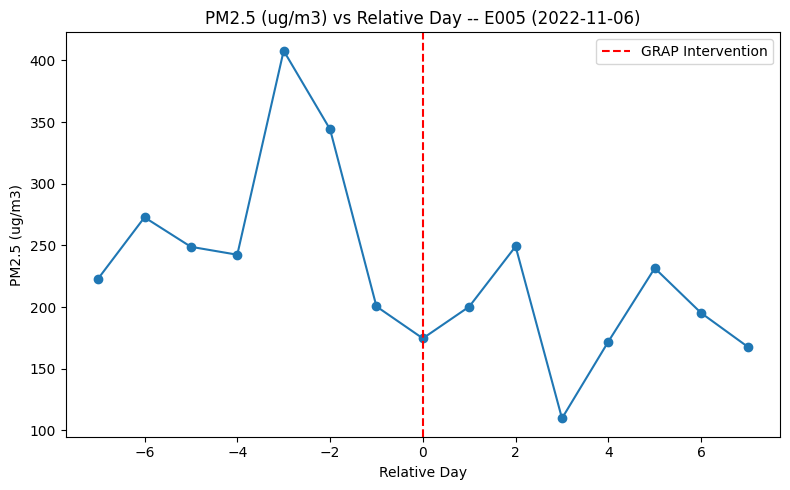

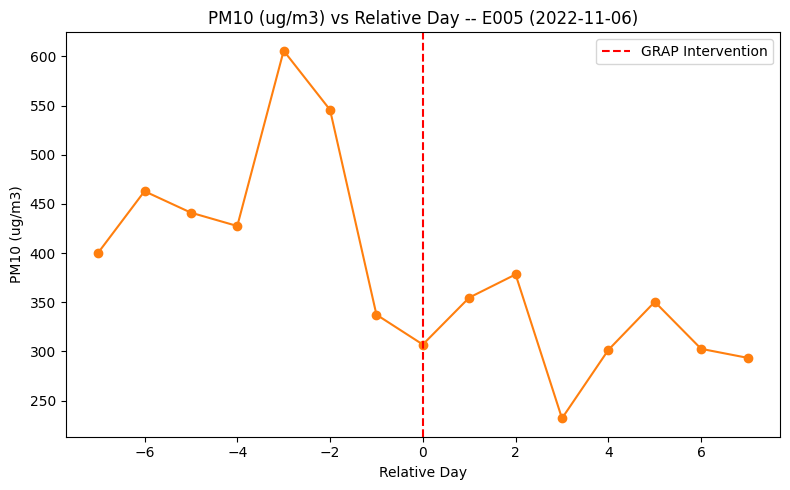

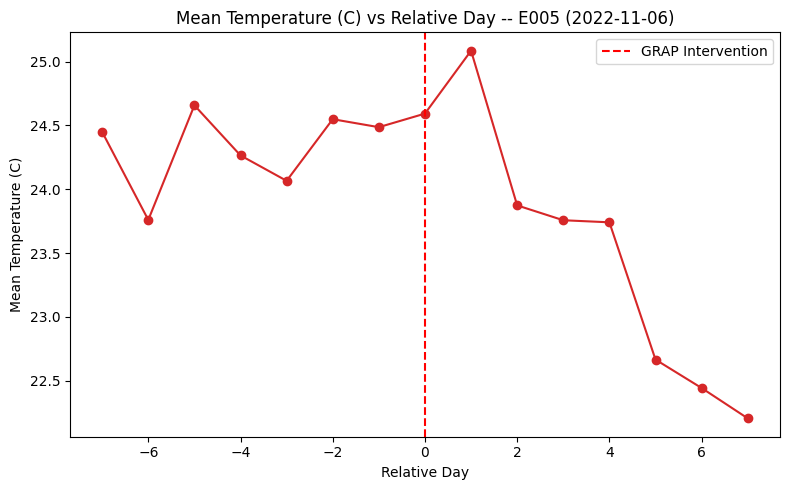

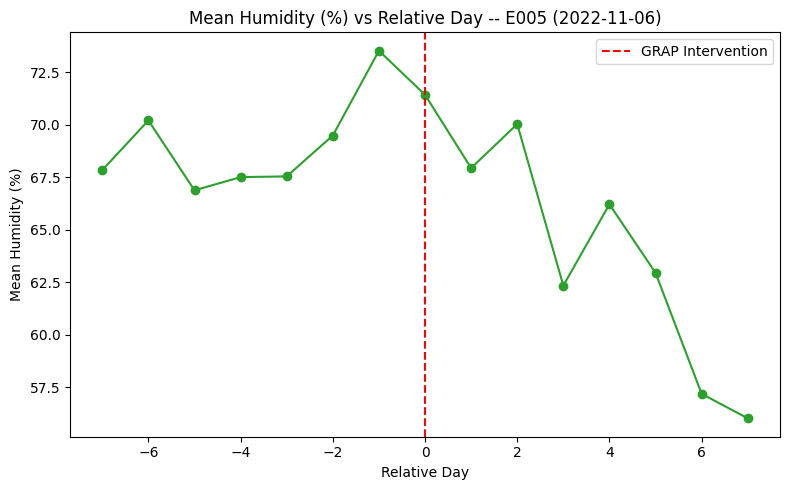

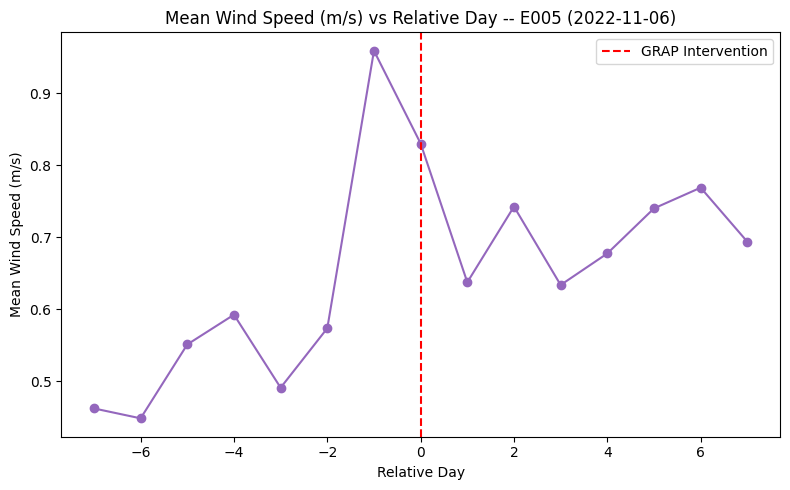

In [16]:
# The five line charts for this event, each averaged across the 8 stations.
plot_event_variable(event_id, '2022-11-06', 'pm25_ugm3', 'PM2.5 (ug/m3)', 'tab:blue')
plot_event_variable(event_id, '2022-11-06', 'pm10_ugm3', 'PM10 (ug/m3)', 'tab:orange')
plot_event_variable(event_id, '2022-11-06', 'air_temp_c', 'Mean Temperature (C)', 'tab:red')
plot_event_variable(event_id, '2022-11-06', 'rh_pct', 'Mean Humidity (%)', 'tab:green')
plot_event_variable(event_id, '2022-11-06', 'wind_speed_ms', 'Mean Wind Speed (m/s)', 'tab:purple')

In [17]:
# Missing-data summary for this event's window: how many of the 8 x 15 = 120
# rows are missing each measured variable.
event_rows = event_windows[event_windows['event_id'] == event_id]
measured_columns = ['pm25_ugm3', 'pm10_ugm3', 'air_temp_c', 'rh_pct', 'wind_speed_ms', 'wind_dir_deg']

missing_summary = event_rows[measured_columns].isnull().sum()
missing_summary = missing_summary.reset_index()
missing_summary.columns = ['Variable', 'Missing Count']
missing_summary['Missing % of Window'] = (missing_summary['Missing Count'] / len(event_rows) * 100).round(1)

missing_summary

,Variable,Missing Count,Missing % of Window
0,pm25_ugm3,0,0.0
1,pm10_ugm3,0,0.0
2,air_temp_c,0,0.0
3,rh_pct,0,0.0
4,wind_speed_ms,0,0.0
5,wind_dir_deg,0,0.0


**How to read these plots.** Each line is the average across the eight
stations for this event only, plotted day by day from 7 days before to 7 days
after the event. The dashed red "GRAP Intervention" line marks relative day 0,
the day the stage change took effect -- it is a time marker, not a claim about
what caused any change on either side of it.

**What analysts should observe.** Look at each line's shape on its own: whether
it is rising, falling, or flat in the days before the marker, and whether that
shape continues, reverses, or stays the same after it. Note how the pollutant
lines (PM2.5, PM10) sit alongside the weather lines (temperature, humidity, wind
speed) in the same window, and check the missing-data summary above before
reading too much into a day with few or no contributing stations.

**What NOT to conclude.** Do not read any change around the dashed line as
proof that the GRAP order caused it -- the same window also contains whatever
weather and seasonal movement was already underway, as documented in
`docs/analysis_plan.md`. Do not compare this event's chart to any other event's
chart -- that comparison is intentionally left for the next notebook. Do not
treat a single day's spike or dip as a stable pattern, and do not draw any
conclusion about whether GRAP is effective from this profile alone.

## Questions Raised

This event's profile raises the following questions, left unanswered here:

1. What happened in the days just before E005 that might be worth a closer look in a later notebook?
2. Does the 4 -> 3 transition on 2022-11-06 line up with a visible change in the PM2.5 line, or not?
3. Do PM2.5 and PM10 move together across this window, or does one lag the other?
4. How much of the shape seen in this window might be explained by the weather charts (temperature, humidity, wind speed) shown alongside it?
5. Would this event's profile look different with a narrower or wider relative-day window, per the sensitivity checks described in the analysis plan?

# Event E006 -- 2022-11-14

In [18]:
# This event's id, used to select its rows out of the shared event-window table.
event_id = 'E006'

event_metadata = grap_events[grap_events['event_id'] == event_id].iloc[0]

event_profile = pd.DataFrame({
    'Field': ['Event ID', 'Event Date', 'Action Type', 'Stage Transition', 'Official Order Title'],
    'Value': [
        event_metadata['event_id'],
        event_metadata['effective_date'].date(),
        event_metadata['action_type'],
        f"Stage {event_metadata['stage_from']} -> Stage {event_metadata['stage_to']}",
        event_metadata['official_order_title'],
    ],
})
event_profile

,Field,Value
0,Event ID,E006
1,Event Date,2022-11-14
2,Action Type,de_escalate
3,Stage Transition,Stage 3 -> Stage 2
4,Official Order Title,Order dated 14.11.2022 for Revocation of actio...


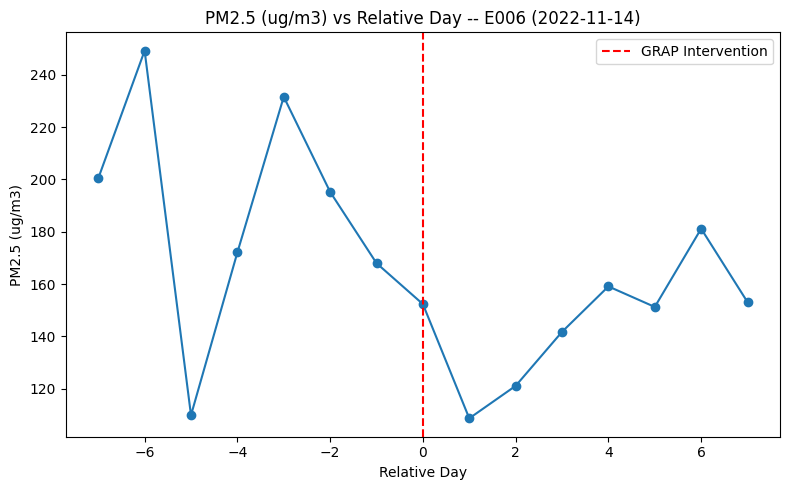

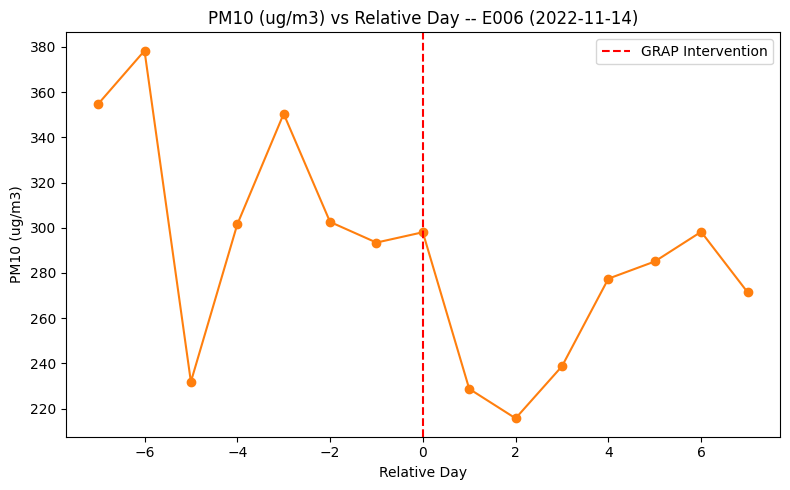

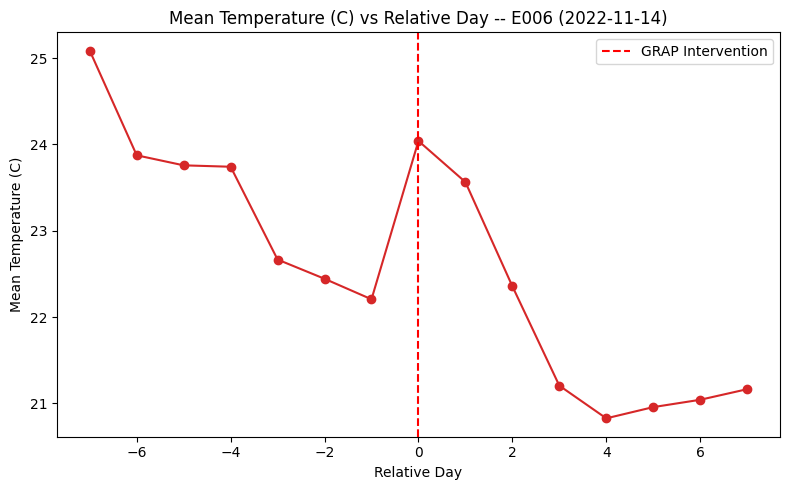

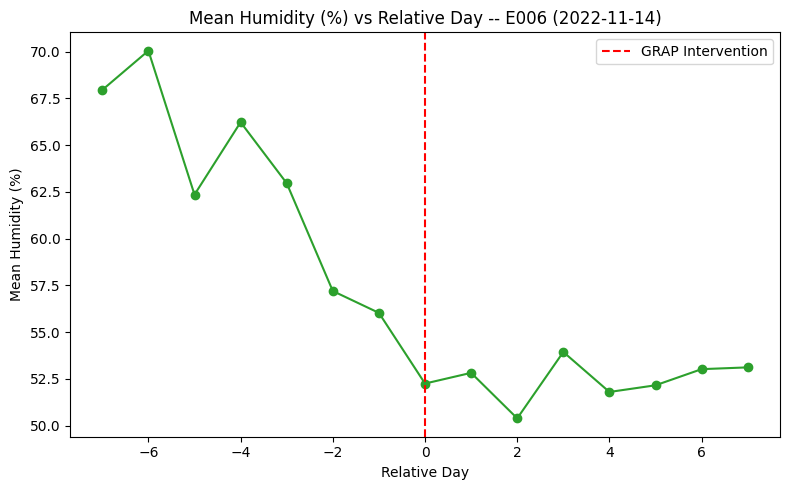

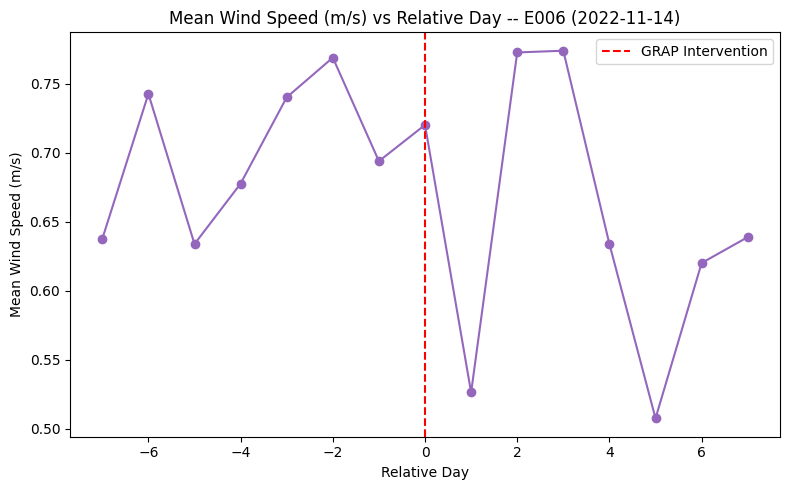

In [19]:
# The five line charts for this event, each averaged across the 8 stations.
plot_event_variable(event_id, '2022-11-14', 'pm25_ugm3', 'PM2.5 (ug/m3)', 'tab:blue')
plot_event_variable(event_id, '2022-11-14', 'pm10_ugm3', 'PM10 (ug/m3)', 'tab:orange')
plot_event_variable(event_id, '2022-11-14', 'air_temp_c', 'Mean Temperature (C)', 'tab:red')
plot_event_variable(event_id, '2022-11-14', 'rh_pct', 'Mean Humidity (%)', 'tab:green')
plot_event_variable(event_id, '2022-11-14', 'wind_speed_ms', 'Mean Wind Speed (m/s)', 'tab:purple')

In [20]:
# Missing-data summary for this event's window: how many of the 8 x 15 = 120
# rows are missing each measured variable.
event_rows = event_windows[event_windows['event_id'] == event_id]
measured_columns = ['pm25_ugm3', 'pm10_ugm3', 'air_temp_c', 'rh_pct', 'wind_speed_ms', 'wind_dir_deg']

missing_summary = event_rows[measured_columns].isnull().sum()
missing_summary = missing_summary.reset_index()
missing_summary.columns = ['Variable', 'Missing Count']
missing_summary['Missing % of Window'] = (missing_summary['Missing Count'] / len(event_rows) * 100).round(1)

missing_summary

,Variable,Missing Count,Missing % of Window
0,pm25_ugm3,0,0.0
1,pm10_ugm3,0,0.0
2,air_temp_c,0,0.0
3,rh_pct,0,0.0
4,wind_speed_ms,0,0.0
5,wind_dir_deg,0,0.0


**How to read these plots.** Each line is the average across the eight
stations for this event only, plotted day by day from 7 days before to 7 days
after the event. The dashed red "GRAP Intervention" line marks relative day 0,
the day the stage change took effect -- it is a time marker, not a claim about
what caused any change on either side of it.

**What analysts should observe.** Look at each line's shape on its own: whether
it is rising, falling, or flat in the days before the marker, and whether that
shape continues, reverses, or stays the same after it. Note how the pollutant
lines (PM2.5, PM10) sit alongside the weather lines (temperature, humidity, wind
speed) in the same window, and check the missing-data summary above before
reading too much into a day with few or no contributing stations.

**What NOT to conclude.** Do not read any change around the dashed line as
proof that the GRAP order caused it -- the same window also contains whatever
weather and seasonal movement was already underway, as documented in
`docs/analysis_plan.md`. Do not compare this event's chart to any other event's
chart -- that comparison is intentionally left for the next notebook. Do not
treat a single day's spike or dip as a stable pattern, and do not draw any
conclusion about whether GRAP is effective from this profile alone.

## Questions Raised

This event's profile raises the following questions, left unanswered here:

1. What happened in the days just before E006 that might be worth a closer look in a later notebook?
2. Does the 3 -> 2 transition on 2022-11-14 line up with a visible change in the PM2.5 line, or not?
3. Do PM2.5 and PM10 move together across this window, or does one lag the other?
4. How much of the shape seen in this window might be explained by the weather charts (temperature, humidity, wind speed) shown alongside it?
5. Would this event's profile look different with a narrower or wider relative-day window, per the sensitivity checks described in the analysis plan?

# Event E007 -- 2022-12-04

In [21]:
# This event's id, used to select its rows out of the shared event-window table.
event_id = 'E007'

event_metadata = grap_events[grap_events['event_id'] == event_id].iloc[0]

event_profile = pd.DataFrame({
    'Field': ['Event ID', 'Event Date', 'Action Type', 'Stage Transition', 'Official Order Title'],
    'Value': [
        event_metadata['event_id'],
        event_metadata['effective_date'].date(),
        event_metadata['action_type'],
        f"Stage {event_metadata['stage_from']} -> Stage {event_metadata['stage_to']}",
        event_metadata['official_order_title'],
    ],
})
event_profile

,Field,Value
0,Event ID,E007
1,Event Date,2022-12-04
2,Action Type,escalate
3,Stage Transition,Stage 2 -> Stage 3
4,Official Order Title,Order dated 04.12.2022 for Implementation of A...


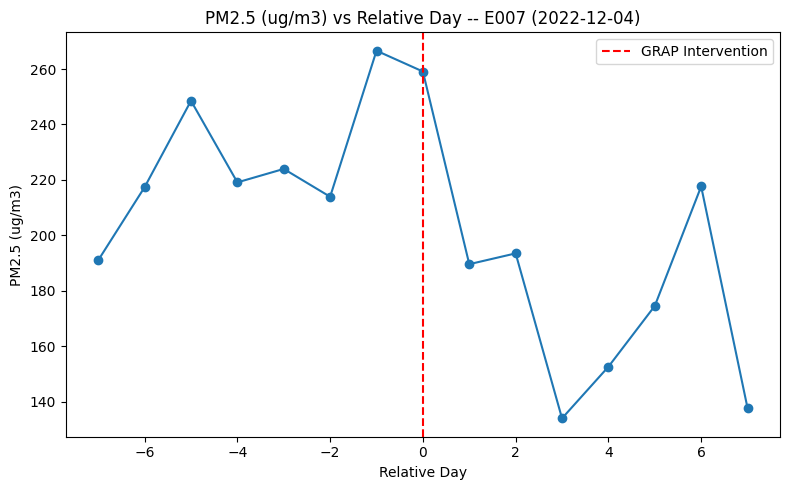

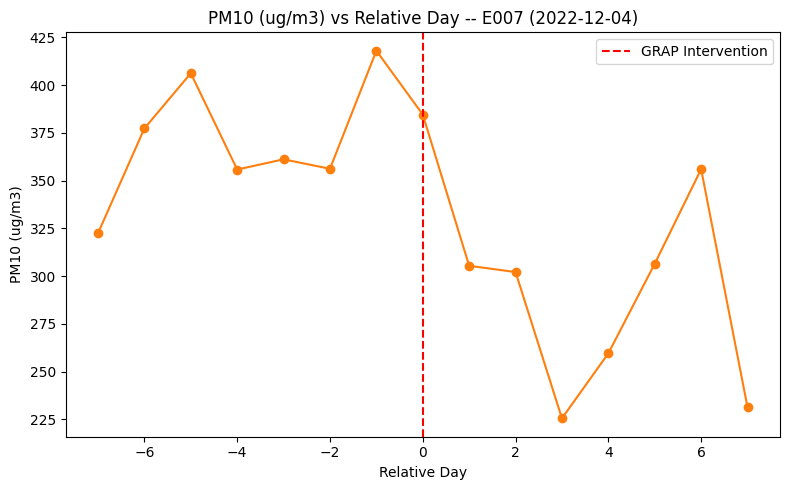

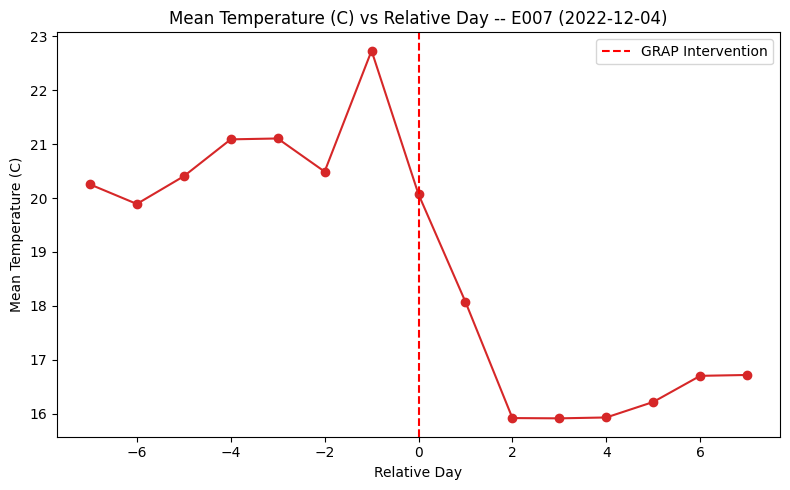

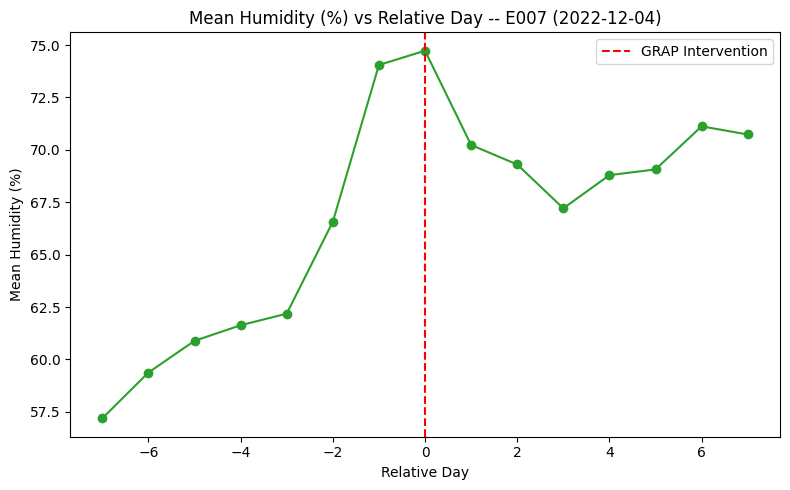

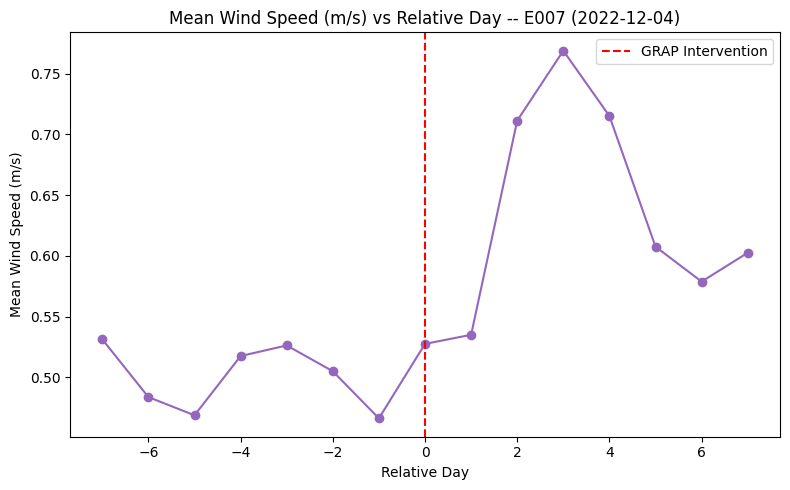

In [22]:
# The five line charts for this event, each averaged across the 8 stations.
plot_event_variable(event_id, '2022-12-04', 'pm25_ugm3', 'PM2.5 (ug/m3)', 'tab:blue')
plot_event_variable(event_id, '2022-12-04', 'pm10_ugm3', 'PM10 (ug/m3)', 'tab:orange')
plot_event_variable(event_id, '2022-12-04', 'air_temp_c', 'Mean Temperature (C)', 'tab:red')
plot_event_variable(event_id, '2022-12-04', 'rh_pct', 'Mean Humidity (%)', 'tab:green')
plot_event_variable(event_id, '2022-12-04', 'wind_speed_ms', 'Mean Wind Speed (m/s)', 'tab:purple')

In [23]:
# Missing-data summary for this event's window: how many of the 8 x 15 = 120
# rows are missing each measured variable.
event_rows = event_windows[event_windows['event_id'] == event_id]
measured_columns = ['pm25_ugm3', 'pm10_ugm3', 'air_temp_c', 'rh_pct', 'wind_speed_ms', 'wind_dir_deg']

missing_summary = event_rows[measured_columns].isnull().sum()
missing_summary = missing_summary.reset_index()
missing_summary.columns = ['Variable', 'Missing Count']
missing_summary['Missing % of Window'] = (missing_summary['Missing Count'] / len(event_rows) * 100).round(1)

missing_summary

,Variable,Missing Count,Missing % of Window
0,pm25_ugm3,2,1.7
1,pm10_ugm3,0,0.0
2,air_temp_c,0,0.0
3,rh_pct,0,0.0
4,wind_speed_ms,0,0.0
5,wind_dir_deg,0,0.0


**How to read these plots.** Each line is the average across the eight
stations for this event only, plotted day by day from 7 days before to 7 days
after the event. The dashed red "GRAP Intervention" line marks relative day 0,
the day the stage change took effect -- it is a time marker, not a claim about
what caused any change on either side of it.

**What analysts should observe.** Look at each line's shape on its own: whether
it is rising, falling, or flat in the days before the marker, and whether that
shape continues, reverses, or stays the same after it. Note how the pollutant
lines (PM2.5, PM10) sit alongside the weather lines (temperature, humidity, wind
speed) in the same window, and check the missing-data summary above before
reading too much into a day with few or no contributing stations.

**What NOT to conclude.** Do not read any change around the dashed line as
proof that the GRAP order caused it -- the same window also contains whatever
weather and seasonal movement was already underway, as documented in
`docs/analysis_plan.md`. Do not compare this event's chart to any other event's
chart -- that comparison is intentionally left for the next notebook. Do not
treat a single day's spike or dip as a stable pattern, and do not draw any
conclusion about whether GRAP is effective from this profile alone.

## Questions Raised

This event's profile raises the following questions, left unanswered here:

1. What happened in the days just before E007 that might be worth a closer look in a later notebook?
2. Does the 2 -> 3 transition on 2022-12-04 line up with a visible change in the PM2.5 line, or not?
3. Do PM2.5 and PM10 move together across this window, or does one lag the other?
4. How much of the shape seen in this window might be explained by the weather charts (temperature, humidity, wind speed) shown alongside it?
5. Would this event's profile look different with a narrower or wider relative-day window, per the sensitivity checks described in the analysis plan?

# Event E008 -- 2022-12-07

In [24]:
# This event's id, used to select its rows out of the shared event-window table.
event_id = 'E008'

event_metadata = grap_events[grap_events['event_id'] == event_id].iloc[0]

event_profile = pd.DataFrame({
    'Field': ['Event ID', 'Event Date', 'Action Type', 'Stage Transition', 'Official Order Title'],
    'Value': [
        event_metadata['event_id'],
        event_metadata['effective_date'].date(),
        event_metadata['action_type'],
        f"Stage {event_metadata['stage_from']} -> Stage {event_metadata['stage_to']}",
        event_metadata['official_order_title'],
    ],
})
event_profile

,Field,Value
0,Event ID,E008
1,Event Date,2022-12-07
2,Action Type,de_escalate
3,Stage Transition,Stage 3 -> Stage 2
4,Official Order Title,Order dated 07.12.2022 for Revocation of actio...


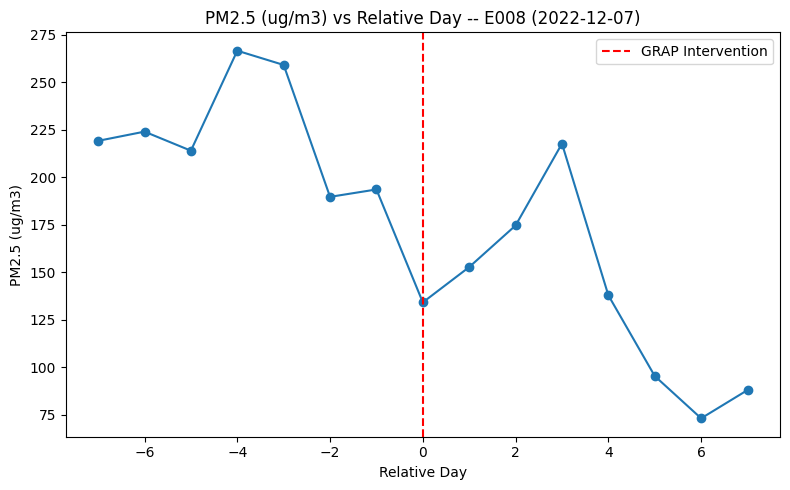

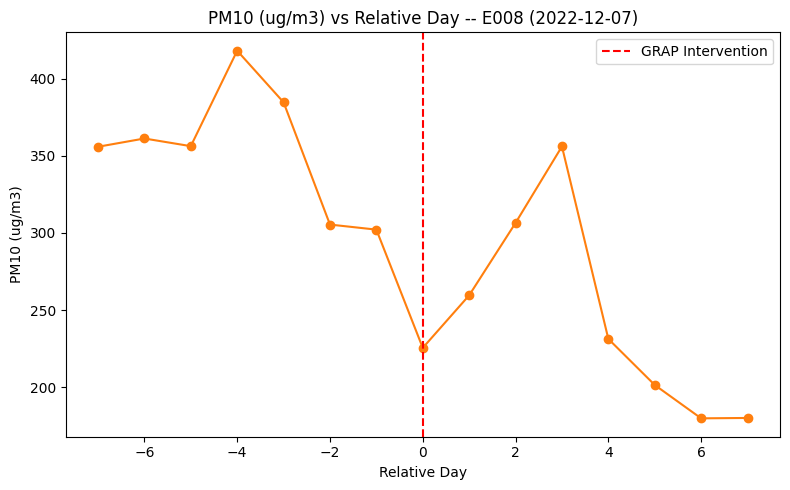

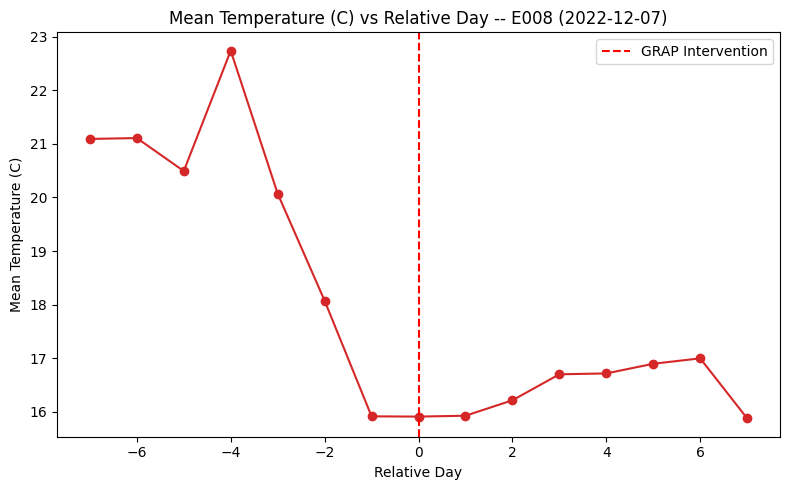

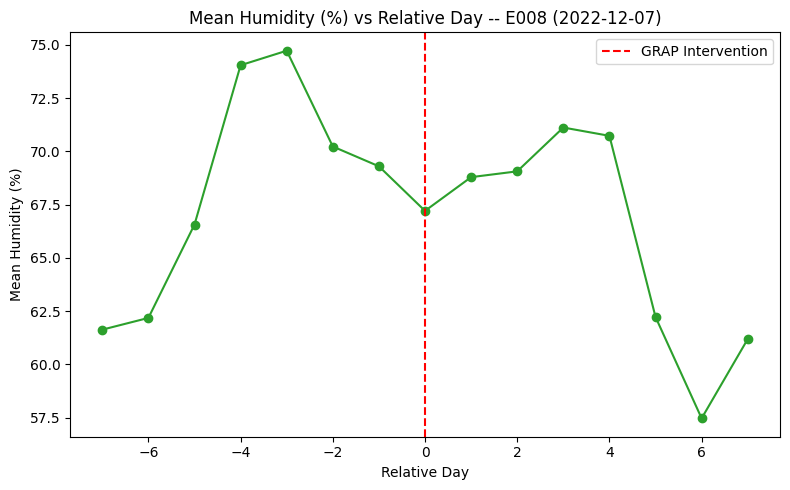

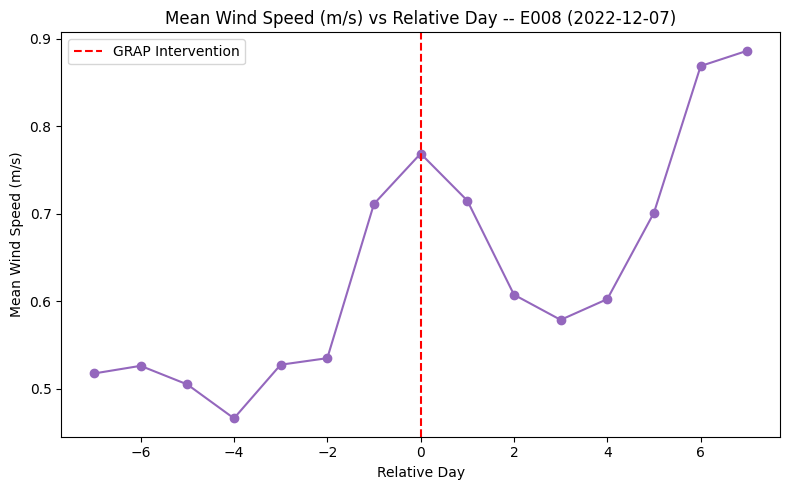

In [25]:
# The five line charts for this event, each averaged across the 8 stations.
plot_event_variable(event_id, '2022-12-07', 'pm25_ugm3', 'PM2.5 (ug/m3)', 'tab:blue')
plot_event_variable(event_id, '2022-12-07', 'pm10_ugm3', 'PM10 (ug/m3)', 'tab:orange')
plot_event_variable(event_id, '2022-12-07', 'air_temp_c', 'Mean Temperature (C)', 'tab:red')
plot_event_variable(event_id, '2022-12-07', 'rh_pct', 'Mean Humidity (%)', 'tab:green')
plot_event_variable(event_id, '2022-12-07', 'wind_speed_ms', 'Mean Wind Speed (m/s)', 'tab:purple')

In [26]:
# Missing-data summary for this event's window: how many of the 8 x 15 = 120
# rows are missing each measured variable.
event_rows = event_windows[event_windows['event_id'] == event_id]
measured_columns = ['pm25_ugm3', 'pm10_ugm3', 'air_temp_c', 'rh_pct', 'wind_speed_ms', 'wind_dir_deg']

missing_summary = event_rows[measured_columns].isnull().sum()
missing_summary = missing_summary.reset_index()
missing_summary.columns = ['Variable', 'Missing Count']
missing_summary['Missing % of Window'] = (missing_summary['Missing Count'] / len(event_rows) * 100).round(1)

missing_summary

,Variable,Missing Count,Missing % of Window
0,pm25_ugm3,0,0.0
1,pm10_ugm3,0,0.0
2,air_temp_c,0,0.0
3,rh_pct,0,0.0
4,wind_speed_ms,0,0.0
5,wind_dir_deg,0,0.0


**How to read these plots.** Each line is the average across the eight
stations for this event only, plotted day by day from 7 days before to 7 days
after the event. The dashed red "GRAP Intervention" line marks relative day 0,
the day the stage change took effect -- it is a time marker, not a claim about
what caused any change on either side of it.

**What analysts should observe.** Look at each line's shape on its own: whether
it is rising, falling, or flat in the days before the marker, and whether that
shape continues, reverses, or stays the same after it. Note how the pollutant
lines (PM2.5, PM10) sit alongside the weather lines (temperature, humidity, wind
speed) in the same window, and check the missing-data summary above before
reading too much into a day with few or no contributing stations.

**What NOT to conclude.** Do not read any change around the dashed line as
proof that the GRAP order caused it -- the same window also contains whatever
weather and seasonal movement was already underway, as documented in
`docs/analysis_plan.md`. Do not compare this event's chart to any other event's
chart -- that comparison is intentionally left for the next notebook. Do not
treat a single day's spike or dip as a stable pattern, and do not draw any
conclusion about whether GRAP is effective from this profile alone.

## Questions Raised

This event's profile raises the following questions, left unanswered here:

1. What happened in the days just before E008 that might be worth a closer look in a later notebook?
2. Does the 3 -> 2 transition on 2022-12-07 line up with a visible change in the PM2.5 line, or not?
3. Do PM2.5 and PM10 move together across this window, or does one lag the other?
4. How much of the shape seen in this window might be explained by the weather charts (temperature, humidity, wind speed) shown alongside it?
5. Would this event's profile look different with a narrower or wider relative-day window, per the sensitivity checks described in the analysis plan?

# Event E009 -- 2022-12-30

In [27]:
# This event's id, used to select its rows out of the shared event-window table.
event_id = 'E009'

event_metadata = grap_events[grap_events['event_id'] == event_id].iloc[0]

event_profile = pd.DataFrame({
    'Field': ['Event ID', 'Event Date', 'Action Type', 'Stage Transition', 'Official Order Title'],
    'Value': [
        event_metadata['event_id'],
        event_metadata['effective_date'].date(),
        event_metadata['action_type'],
        f"Stage {event_metadata['stage_from']} -> Stage {event_metadata['stage_to']}",
        event_metadata['official_order_title'],
    ],
})
event_profile

,Field,Value
0,Event ID,E009
1,Event Date,2022-12-30
2,Action Type,escalate
3,Stage Transition,Stage 2 -> Stage 3
4,Official Order Title,Order dated 30.12.2022 for implementation of a...


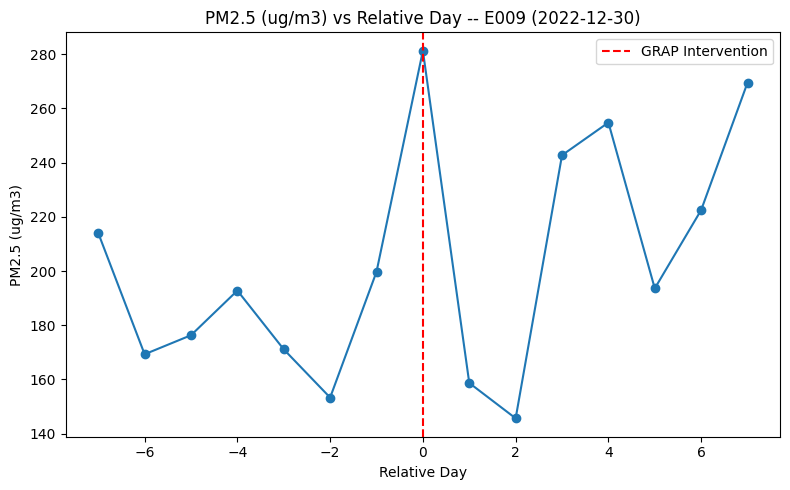

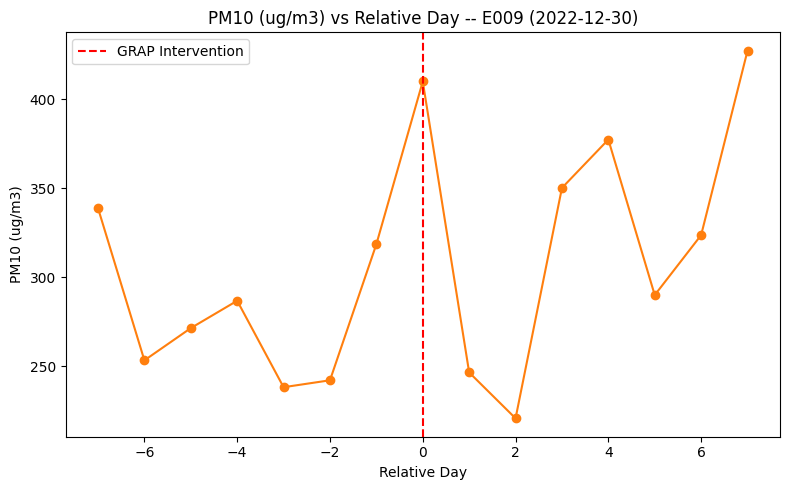

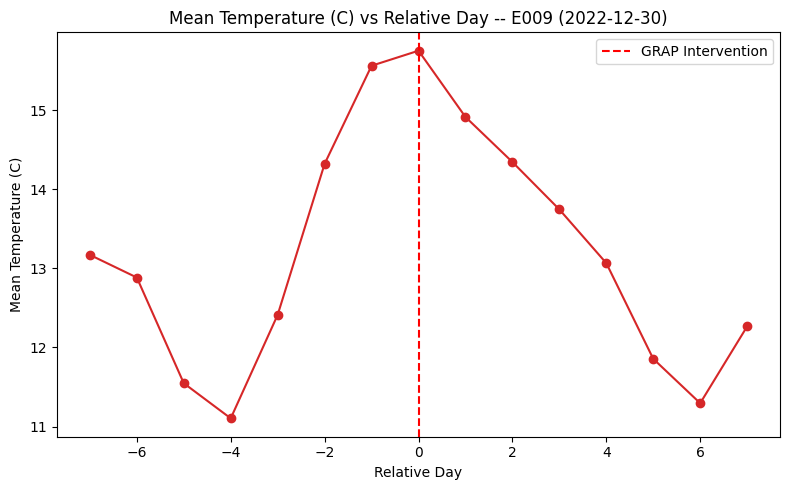

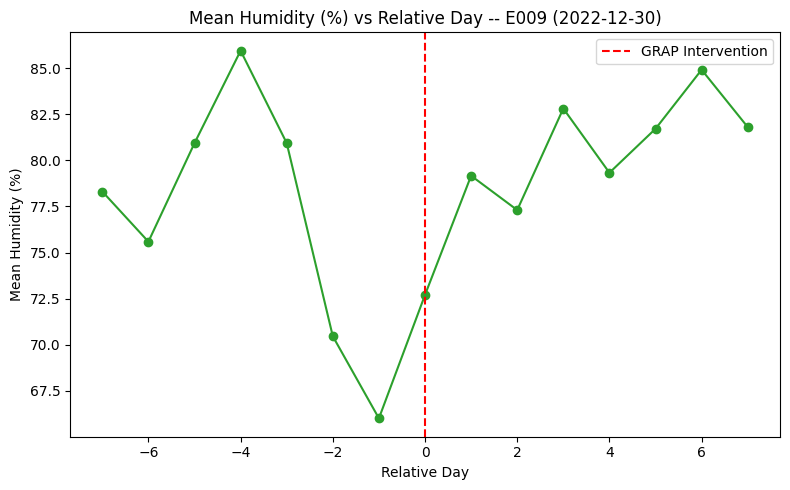

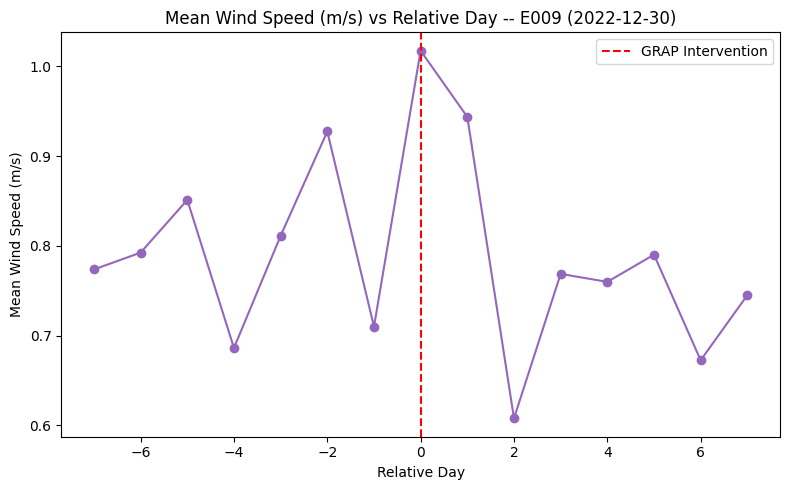

In [28]:
# The five line charts for this event, each averaged across the 8 stations.
plot_event_variable(event_id, '2022-12-30', 'pm25_ugm3', 'PM2.5 (ug/m3)', 'tab:blue')
plot_event_variable(event_id, '2022-12-30', 'pm10_ugm3', 'PM10 (ug/m3)', 'tab:orange')
plot_event_variable(event_id, '2022-12-30', 'air_temp_c', 'Mean Temperature (C)', 'tab:red')
plot_event_variable(event_id, '2022-12-30', 'rh_pct', 'Mean Humidity (%)', 'tab:green')
plot_event_variable(event_id, '2022-12-30', 'wind_speed_ms', 'Mean Wind Speed (m/s)', 'tab:purple')

In [29]:
# Missing-data summary for this event's window: how many of the 8 x 15 = 120
# rows are missing each measured variable.
event_rows = event_windows[event_windows['event_id'] == event_id]
measured_columns = ['pm25_ugm3', 'pm10_ugm3', 'air_temp_c', 'rh_pct', 'wind_speed_ms', 'wind_dir_deg']

missing_summary = event_rows[measured_columns].isnull().sum()
missing_summary = missing_summary.reset_index()
missing_summary.columns = ['Variable', 'Missing Count']
missing_summary['Missing % of Window'] = (missing_summary['Missing Count'] / len(event_rows) * 100).round(1)

missing_summary

,Variable,Missing Count,Missing % of Window
0,pm25_ugm3,0,0.0
1,pm10_ugm3,0,0.0
2,air_temp_c,0,0.0
3,rh_pct,0,0.0
4,wind_speed_ms,0,0.0
5,wind_dir_deg,0,0.0


**How to read these plots.** Each line is the average across the eight
stations for this event only, plotted day by day from 7 days before to 7 days
after the event. The dashed red "GRAP Intervention" line marks relative day 0,
the day the stage change took effect -- it is a time marker, not a claim about
what caused any change on either side of it.

**What analysts should observe.** Look at each line's shape on its own: whether
it is rising, falling, or flat in the days before the marker, and whether that
shape continues, reverses, or stays the same after it. Note how the pollutant
lines (PM2.5, PM10) sit alongside the weather lines (temperature, humidity, wind
speed) in the same window, and check the missing-data summary above before
reading too much into a day with few or no contributing stations.

**What NOT to conclude.** Do not read any change around the dashed line as
proof that the GRAP order caused it -- the same window also contains whatever
weather and seasonal movement was already underway, as documented in
`docs/analysis_plan.md`. Do not compare this event's chart to any other event's
chart -- that comparison is intentionally left for the next notebook. Do not
treat a single day's spike or dip as a stable pattern, and do not draw any
conclusion about whether GRAP is effective from this profile alone.

## Questions Raised

This event's profile raises the following questions, left unanswered here:

1. What happened in the days just before E009 that might be worth a closer look in a later notebook?
2. Does the 2 -> 3 transition on 2022-12-30 line up with a visible change in the PM2.5 line, or not?
3. Do PM2.5 and PM10 move together across this window, or does one lag the other?
4. How much of the shape seen in this window might be explained by the weather charts (temperature, humidity, wind speed) shown alongside it?
5. Would this event's profile look different with a narrower or wider relative-day window, per the sensitivity checks described in the analysis plan?

# Cross-Event Preview

Each event above has been described entirely on its own terms -- its own
metadata, its own five charts, its own missing-data summary, and its own
questions. No event's numbers have been placed next to another event's numbers
anywhere in this notebook.

The next notebook in this project will take up that comparison directly: lining
the nine event profiles built here up against one another to look at
cross-event consistency, as set out in the analytical sequence in
`docs/analysis_plan.md`. That comparison is not performed here.

*End of the Event Profile Analysis notebook.*